In [1]:
import pandas as pd
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score
import matplotlib.pyplot as plt
from sklearn.preprocessing import PolynomialFeatures

In [2]:
df = pd.read_csv('regression_table.csv')

In [3]:
df.describe()

,X,Y
count,1.000000e+03,1000.000000
mean,7.275958e-15,-0.056852
std,2.891085e+01,0.951317
min,-5.000000e+01,-3.565291
25%,-2.500000e+01,-0.682682
50%,3.552714e-15,-0.024003
75%,2.500000e+01,0.572795
max,5.000000e+01,2.788375


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   X       1000 non-null   float64
 1   Y       1000 non-null   float64
dtypes: float64(2)
memory usage: 15.8 KB


In [5]:
df.corr()

,X,Y
X,1.000000,0.320008
Y,0.320008,1.000000


In [6]:
x = df.drop(columns='Y') #feature cols(2D)
y = df['X'] #target cols(1D)

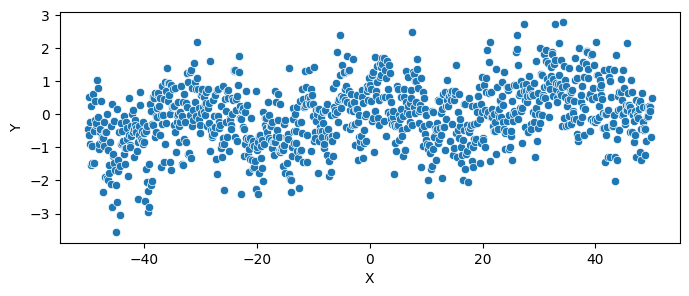

In [7]:
plt.figure(figsize=(8, 3))
sns.scatterplot(df, x="X", y= "Y")
plt.show()

In [8]:
xtrain,xtest,ytrain,ytest = train_test_split(x,y,test_size=0.2,random_state=42)

In [9]:
model = LinearRegression() #model creation
model.fit(xtrain, ytrain)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](1,)",[1.]
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](1,)",['X']
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,-8.327e-17
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,1
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(1)


In [10]:
#model evaluation
#train data
ytrain_pred = model.predict(xtrain)
train_score = r2_score(ytrain,ytrain_pred)
print(f'Train score: {train_score}')

#test data
ytest_pred = model.predict(xtest)
test_score = r2_score(ytest,ytest_pred)
print(f'Train score: {train_score}')

Train score: 1.0
Train score: 1.0


In [11]:
xtrain

,X
29,-47.097097
535,3.553554
695,19.569570
557,5.755756
836,33.683684
...,...
106,-39.389389
270,-22.972973
860,36.086086
435,-6.456456


In [12]:
poly = PolynomialFeatures(degree=7)
updated_xtrain = poly.fit_transform(xtrain)

In [13]:
updated_xtest = poly.transform(xtest)

In [14]:
model_poly = LinearRegression()
model_poly.fit(updated_xtrain, ytrain)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](8,)","[ 0., 0., 0.,..., 0.,-0.,-0.]"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,0.06387
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,8
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(4)
"singular_ singular_: array of shape (min(X, y),)Singular values of `X`. Only available when `X` is dense.","ndarray[float64](8,)","[5.78e+12,1.06e+11,4.16e+08,...,2.68e+03,1.24e+02,0.00e+00]"


In [ ]:
# Model Evaluation
# Train Data
ytrain_pred = model_poly.predict(updated_xtrain)
train_score = r2_score(ytrain, ytrain_pred)
print(f"Train Score: {train_score}")

# Test Data
ytest_pred = model_poly.predict(updated_xtest)
test_score = r2_score(ytest, ytest_pred)
print(f"Test Score: {test_score}")

Train Score: 0.8590076901589864
Test Score: 0.837086813815447


CHECKING THE DEGREE AND THE MODEL PERFORMANCE:-


(degree=2)
Train Score: 1.0
Test Score: 1.0
MODEL PERFORMANCE-OVERFIT


(degree=3)
Train Score: 1.0
Test Score: 1.0
MODEL PERFORMANCE-OVERFIT

(degree=4)
Train Score: 1.0
Test Score: 1.0
MODEL PERFORMANCE-OVERFIT

(degree=5)
Train Score: 0.9493596710317699
Test Score: 0.9405669396454021
MODEL PERFORMANCE- GOODFIT


(degree=6)
Train Score: 0.9493290853880945
Test Score: 0.9408483049216689
MODEL PERFORMANCE- GOODFIT

(degree=7)
Train Score: 0.8590076901589864
Test Score: 0.837086813815447
MODEL PERFORMANCE- GOODFIT

CONCLUSION:-

In (degree=5),(degree=6),(degree=7) ,the model performance is Good Fit because the model captures both the train data and test data pattern.By using (degree=5),(degree=6),(degree=7),it acts or creates new features to handle non linear data pattern.It is generalised well.